📸 Total images      : 2009
🏷️  Total annotations : 4737
📦 Classes           : 3

   0. pothole              → 1261 annotations
   1. crack                → 2519 annotations
   2. manhole              → 957 annotations


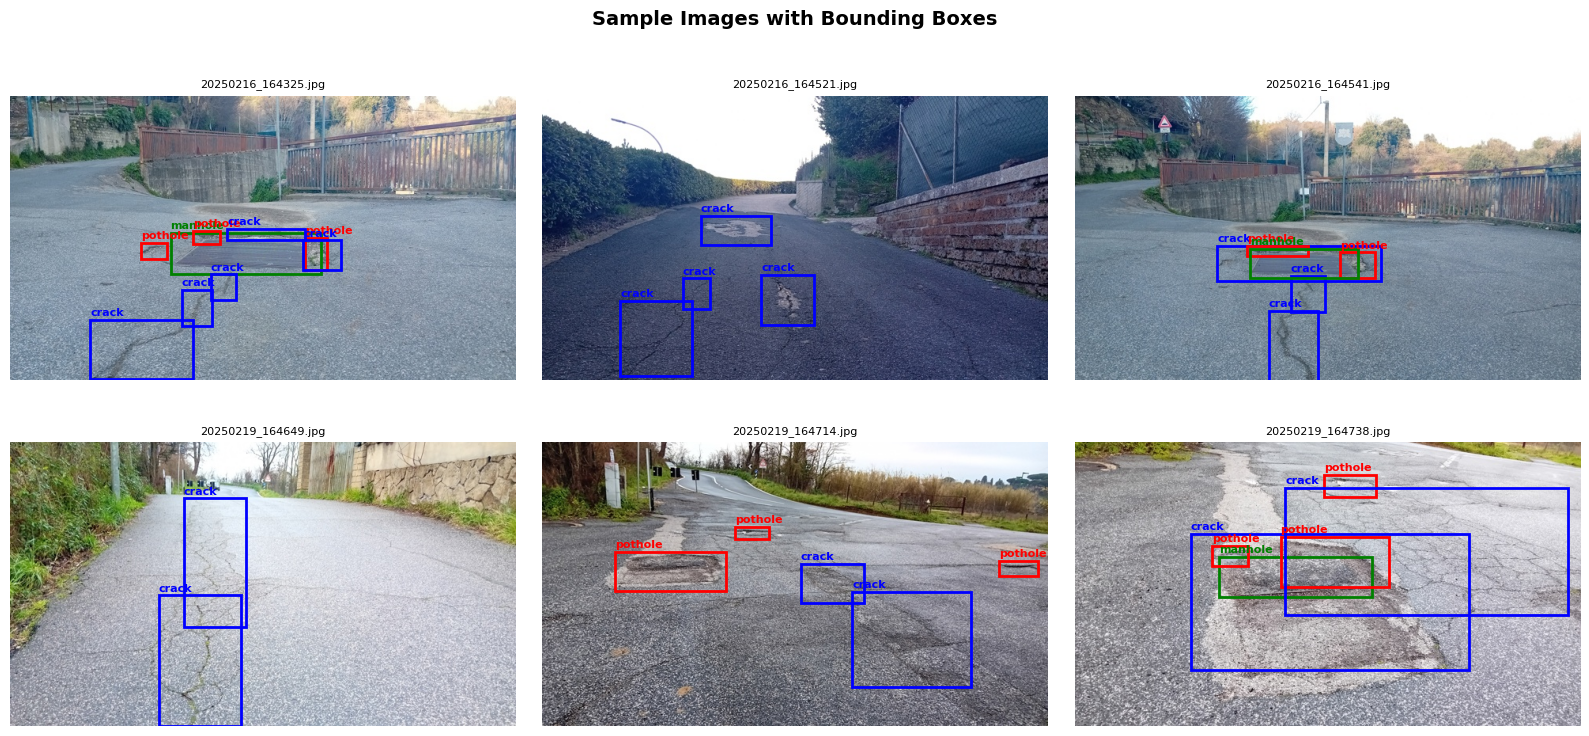

✅ Done! Saved to results/sample_images.png


In [13]:
# ============================================================
# Cell 1: Explore Dataset
# ============================================================
import json
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# ── Paths ──────────────────────────────────────────────────
BASE_DIR   = os.path.join("dataset", "data")
IMG_DIR    = os.path.join(BASE_DIR, "images")
COCO_FILE  = os.path.join(BASE_DIR, "annotations_coco.json")

# ── Load COCO annotations ───────────────────────────────────
with open(COCO_FILE, "r") as f:
    coco = json.load(f)

# ── Basic stats ─────────────────────────────────────────────
print(f"📸 Total images      : {len(coco['images'])}")
print(f"🏷️  Total annotations : {len(coco['annotations'])}")
print(f"📦 Classes           : {len(coco['categories'])}")
print()

for cat in coco['categories']:
    count = sum(1 for a in coco['annotations'] if a['category_id'] == cat['id'])
    print(f"   {cat['id']}. {cat['name']:20s} → {count} annotations")

# ── Show 6 sample images with bounding boxes ────────────────
sample_imgs = coco['images'][:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

id_to_name = {cat['id']: cat['name'] for cat in coco['categories']}
colors = {cat['id']: color for cat, color in zip(coco['categories'],
          ['red', 'blue', 'green'])}

for ax, img_info in zip(axes, sample_imgs):
    img_path = os.path.join(IMG_DIR, img_info['file_name'])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)

    anns = [a for a in coco['annotations'] if a['image_id'] == img_info['id']]
    for ann in anns:
        x, y, w, h = ann['bbox']
        cat_id = ann['category_id']
        rect = patches.Rectangle((x, y), w, h,
                                  linewidth=2,
                                  edgecolor=colors[cat_id],
                                  facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 5, id_to_name[cat_id],
                color=colors[cat_id], fontsize=8, fontweight='bold')

    ax.set_title(img_info['file_name'], fontsize=8)
    ax.axis('off')

plt.suptitle("Sample Images with Bounding Boxes", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join("results", "sample_images.png"), dpi=150)
plt.show()
print("✅ Done! Saved to results/sample_images.png")

In [14]:
# ============================================================
# Cell 2: Crop & Save images per class (Classification Setup)
# ============================================================
import os, json, cv2
from collections import defaultdict

BASE_DIR  = os.path.join("dataset", "data")
IMG_DIR   = os.path.join(BASE_DIR, "images")
COCO_FILE = os.path.join(BASE_DIR, "annotations_coco.json")
CROP_DIR  = os.path.join("dataset", "cropped")

with open(COCO_FILE) as f:
    coco = json.load(f)

id_to_file = {img['id']: img['file_name'] for img in coco['images']}
id_to_name = {cat['id']: cat['name'] for cat in coco['categories']}

# Create output folders
for cat in coco['categories']:
    os.makedirs(os.path.join(CROP_DIR, cat['name']), exist_ok=True)

# Crop each bounding box
counts = defaultdict(int)
skipped = 0

for ann in coco['annotations']:
    img_file = id_to_file[ann['image_id']]
    cat_name = id_to_name[ann['category_id']]
    x, y, w, h = [int(v) for v in ann['bbox']]

    img_path = os.path.join(IMG_DIR, img_file)
    img = cv2.imread(img_path)
    if img is None:
        skipped += 1
        continue

    # Make sure bbox is valid
    H, W = img.shape[:2]
    x, y = max(0, x), max(0, y)
    w, h = min(w, W - x), min(h, H - y)

    if w < 10 or h < 10:
        skipped += 1
        continue

    crop = img[y:y+h, x:x+w]
    crop = cv2.resize(crop, (224, 224))

    save_name = f"{ann['image_id']}_{ann['id']}.jpg"
    save_path = os.path.join(CROP_DIR, cat_name, save_name)
    cv2.imwrite(save_path, crop)
    counts[cat_name] += 1

print("✅ Cropping Done!\n")
print("📊 Crops per class:")
for cls, cnt in counts.items():
    print(f"   {cls:15s}: {cnt} images")
print(f"\n⚠️  Skipped: {skipped}")
print(f"📁 Saved to: {CROP_DIR}")

✅ Cropping Done!

📊 Crops per class:
   manhole        : 901 images
   pothole        : 1192 images
   crack          : 2508 images

⚠️  Skipped: 136
📁 Saved to: dataset\cropped


In [15]:
# ============================================================
# Cell 3: Preprocessing + Split (FIXED)
# ============================================================
import os, shutil, cv2
import numpy as np
from pathlib import Path
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, save_img

CROP_DIR  = Path("dataset/cropped")
AUG_DIR   = Path("dataset/augmented")    # balanced copy
CLASSES   = ["manhole", "pothole", "crack"]
IMG_SIZE  = 128                          # ← was 64, now 128
SEED      = 42

# ── Step 1: count originals ──────────────────────────────────
counts = {cls: len(list((CROP_DIR / cls).glob("*.*"))) for cls in CLASSES}
print("Original counts:", counts)
max_count = max(counts.values())         # 2508

# ── Step 2: disk augmentation for minority classes ───────────
minority_aug = ImageDataGenerator(
    rotation_range=30, horizontal_flip=True,
    zoom_range=0.25, brightness_range=[0.7, 1.3],
    width_shift_range=0.15, height_shift_range=0.15,
    shear_range=10, fill_mode="nearest"
)
majority_aug = ImageDataGenerator(
    rotation_range=10, horizontal_flip=True,
    zoom_range=0.05, fill_mode="nearest"
)

def augment_to_target(cls_name, target, augmenter):
    src = CROP_DIR / cls_name
    dst = AUG_DIR  / cls_name
    dst.mkdir(parents=True, exist_ok=True)
    originals = list(src.glob("*.*"))
    for f in originals:
        shutil.copy(f, dst / f.name)
    needed = target - len(originals)
    if needed <= 0:
        print(f"  {cls_name}: no extra needed"); return
    print(f"  {cls_name}: generating {needed} images...")
    idx = 0
    while idx < needed:
        src_img = np.random.choice(originals)
        arr = img_to_array(load_img(src_img, target_size=(IMG_SIZE, IMG_SIZE)))[np.newaxis]
        for batch in augmenter.flow(arr, batch_size=1, seed=SEED + idx):
            save_img(str(dst / f"syn_{cls_name}_{idx:05d}.jpg"), batch[0])
            idx += 1; break

for cls in CLASSES:
    aug = minority_aug if counts[cls] < max_count else majority_aug
    augment_to_target(cls, max_count, aug)

new_counts = {cls: len(list((AUG_DIR / cls).glob("*.*"))) for cls in CLASSES}
print("\nBalanced counts:", new_counts)

# ── Step 3: load into numpy arrays ──────────────────────────
print("\nLoading images at 128×128 ...")
X, y = [], []
for label, cls in enumerate(CLASSES):
    for fpath in (AUG_DIR / cls).glob("*.*"):
        img = cv2.imread(str(fpath))
        if img is None: continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        X.append(img); y.append(label)

X = np.array(X, dtype="float32") / 255.0
y = np.array(y)
print(f"Loaded: {X.shape}")

# ── Step 4: class weights from ORIGINAL counts ───────────────
y_orig = []
for i, cls in enumerate(CLASSES):
    y_orig.extend([i] * counts[cls])
cw = compute_class_weight("balanced", classes=np.unique(y_orig), y=np.array(y_orig))
class_weight_dict = dict(enumerate(cw))
print("\nClass weights:", {CLASSES[i]: round(v, 4) for i, v in class_weight_dict.items()})

# ── Step 5: 70/15/15 split ───────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)
print(f"Train={len(X_train)} | Val={len(X_val)} | Test={len(X_test)}")

np.save("dataset/X_train.npy", X_train); np.save("dataset/y_train.npy", y_train)
np.save("dataset/X_val.npy",   X_val);   np.save("dataset/y_val.npy",   y_val)
np.save("dataset/X_test.npy",  X_test);  np.save("dataset/y_test.npy",  y_test)
print("Saved ✅")

Original counts: {'manhole': 901, 'pothole': 1192, 'crack': 2508}
  manhole: generating 1607 images...
  pothole: generating 1316 images...
  crack: no extra needed

Balanced counts: {'manhole': 2508, 'pothole': 2508, 'crack': 2508}

Loading images at 128×128 ...
Loaded: (7524, 128, 128, 3)

Class weights: {'manhole': 1.7022, 'pothole': 1.2866, 'crack': 0.6115}
Train=5266 | Val=1129 | Test=1129
Saved ✅


In [8]:
# ============================================================
# Cell 4: Augmentation (FIXED — rescale on ALL generators)
# ============================================================
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 32   # ← lowered from 64; better gradient updates

train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,          # already normalized, but safe to keep
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode="nearest"
)

# ⚠️ FIXED: was ImageDataGenerator() — no rescale!
val_test_datagen = ImageDataGenerator()  # data already /255 from Cell 3

train_gen = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=42)
val_gen   = val_test_datagen.flow(X_val,   y_val,   batch_size=BATCH_SIZE, shuffle=False)
test_gen  = val_test_datagen.flow(X_test,  y_test,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train steps: {len(train_gen)} | Val steps: {len(val_gen)}")

Train steps: 165 | Val steps: 36


In [16]:
# ============================================================
# Cell 5 (FIXED): Reload data → rebuild generators → train
# ============================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import time
import os

os.makedirs("models", exist_ok=True)

# ── Step 1: Reload normalized arrays ────────────────────────
X_train = np.load("dataset/X_train.npy")
X_val   = np.load("dataset/X_val.npy")
X_test  = np.load("dataset/X_test.npy")
y_train = np.load("dataset/y_train.npy")
y_val   = np.load("dataset/y_val.npy")
y_test  = np.load("dataset/y_test.npy")

print("X_train:", X_train.min(), "→", X_train.max())
print("X_val  :", X_val.min(),   "→", X_val.max())
print("X_test :", X_test.min(),  "→", X_test.max())
assert X_train.max() <= 1.0, "❌ X_train is NOT normalized!"
assert X_val.max()   <= 1.0, "❌ X_val is NOT normalized!"
print("✅ All arrays normalized [0, 1]")

# ── Step 2: Rebuild generators ───────────────────────────────
BATCH_SIZE = 32

train_datagen    = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode="nearest"
)
val_test_datagen = ImageDataGenerator()  # no rescale — already [0,1]

train_gen = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=42)
val_gen   = val_test_datagen.flow(X_val,   y_val,   batch_size=BATCH_SIZE, shuffle=False)
test_gen  = val_test_datagen.flow(X_test,  y_test,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train steps: {len(train_gen)} | Val steps: {len(val_gen)}")

# ── Step 3: Rebuild class weights ────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

CLASSES = ["crack", "manhole", "pothole"]
original_counts = [901, 1192, 2508]

y_orig = []
for i, cnt in enumerate(original_counts):
    y_orig.extend([i] * cnt)

cw = compute_class_weight("balanced", classes=np.unique(y_orig), y=np.array(y_orig))
class_weight_dict = dict(enumerate(cw))
print("Class weights:", {CLASSES[i]: round(v, 4) for i, v in class_weight_dict.items()})

# ── Step 4: Build model ──────────────────────────────────────
IMG_SIZE    = 128
NUM_CLASSES = 3
L2          = 1e-4

def build_cnn_scratch():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation="relu", padding="same",
                      kernel_regularizer=regularizers.l2(L2),
                      input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 2
        layers.Conv2D(64, (3,3), activation="relu", padding="same",
                      kernel_regularizer=regularizers.l2(L2)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 3
        layers.Conv2D(128, (3,3), activation="relu", padding="same",
                      kernel_regularizer=regularizers.l2(L2)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 4
        layers.Conv2D(256, (3,3), activation="relu", padding="same",
                      kernel_regularizer=regularizers.l2(L2)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Classifier head
        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])
    return model

cnn_scratch = build_cnn_scratch()
cnn_scratch.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
cnn_scratch.summary()

# ── Step 5: Train ────────────────────────────────────────────
callbacks_scratch = [
    EarlyStopping(monitor="val_loss", patience=8,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint("models/cnn_scratch_best.h5",
                    monitor="val_loss", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=3, verbose=1, min_lr=1e-6)
]

print("\nTraining CNN from Scratch...")
start = time.time()
history_scratch = cnn_scratch.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_scratch,
    verbose=1
)
print(f"\nTraining time: {(time.time()-start)/60:.2f} min")

X_train: 0.0 → 1.0
X_val  : 0.0 → 1.0
X_test : 0.0 → 1.0
✅ All arrays normalized [0, 1]
Train steps: 165 | Val steps: 36
Class weights: {'crack': 1.7022, 'manhole': 1.2866, 'pothole': 0.6115}
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 batch_normalization_2 (Bat  (None, 128, 128, 32)      128       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 64, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                              

c:\Users\Fatma Ahmed\.conda\envs\road_damage\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


165/165 [==============================] - 150s 899ms/step - loss: 1.5954 - accuracy: 0.4442 - val_loss: 1.9757 - val_accuracy: 0.3118 - lr: 0.0010
Epoch 2/50
165/165 [==============================] - ETA: 0s - loss: 1.2635 - accuracy: 0.5165
Epoch 2: val_loss improved from 1.97574 to 0.95999, saving model to models\cnn_scratch_best.h5
165/165 [==============================] - 135s 817ms/step - loss: 1.2635 - accuracy: 0.5165 - val_loss: 0.9600 - val_accuracy: 0.5323 - lr: 0.0010
Epoch 3/50
165/165 [==============================] - ETA: 0s - loss: 1.0951 - accuracy: 0.5642
Epoch 3: val_loss did not improve from 0.95999
165/165 [==============================] - 121s 731ms/step - loss: 1.0951 - accuracy: 0.5642 - val_loss: 1.1659 - val_accuracy: 0.4827 - lr: 0.0010
Epoch 4/50
165/165 [==============================] - ETA: 0s - loss: 0.9941 - accuracy: 0.6063
Epoch 4: val_loss improved from 0.95999 to 0.85261, saving model to models\cnn_scratch_best.h5
165/165 [======================

36/36 [==============================] - 5s 131ms/step
   CNN from Scratch — Test Results
  Test Accuracy  : 0.8096 (80.96%)
  Test Loss      : 0.4745
  Precision      : 0.8106
  Recall         : 0.8096
  F1-Score       : 0.8079

📋 Classification Report:
              precision    recall  f1-score   support

       crack       0.76      0.86      0.81       376
     manhole       0.78      0.68      0.73       377
     pothole       0.89      0.88      0.89       376

    accuracy                           0.81      1129
   macro avg       0.81      0.81      0.81      1129
weighted avg       0.81      0.81      0.81      1129



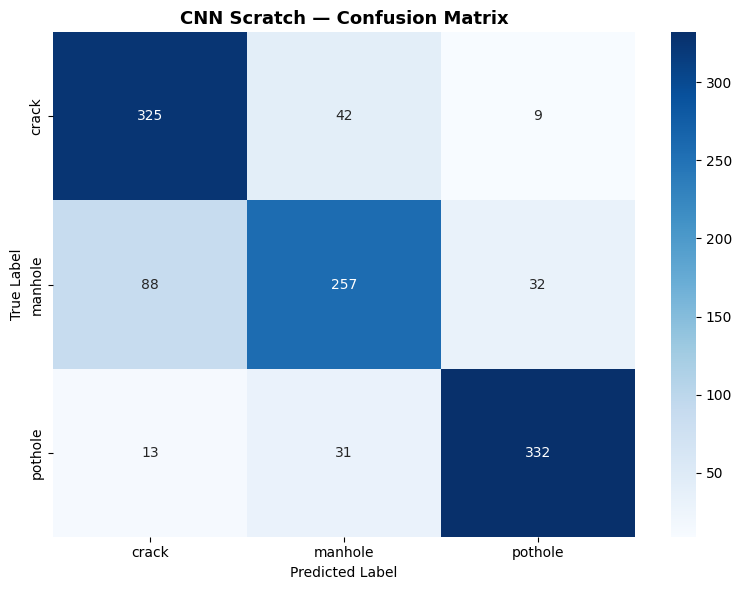

✅ Results saved for final comparison!


In [18]:
# ============================================================
# Cell 7: Evaluate CNN Scratch on Test Set
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score)

CLASSES = ["crack", "manhole", "pothole"]

# ── Predictions ──────────────────────────────────────────────
y_pred_probs = cnn_scratch.predict(X_test, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)

# ── Metrics ──────────────────────────────────────────────────
test_loss, test_acc = cnn_scratch.evaluate(X_test, y_test, verbose=0)

precision = precision_score(y_test, y_pred, average="weighted")
recall    = recall_score(y_test, y_pred, average="weighted")
f1        = f1_score(y_test, y_pred, average="weighted")

print("=" * 50)
print("   CNN from Scratch — Test Results")
print("=" * 50)
print(f"  Test Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Test Loss      : {test_loss:.4f}")
print(f"  Precision      : {precision:.4f}")
print(f"  Recall         : {recall:.4f}")
print(f"  F1-Score       : {f1:.4f}")
print("=" * 50)
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASSES))

# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("CNN Scratch — Confusion Matrix", fontweight="bold", fontsize=13)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(os.path.join("results", "scratch_confusion_matrix.png"), dpi=150)
plt.show()

# ── Save results for comparison later ────────────────────────
scratch_results = {
    "accuracy"  : test_acc,
    "precision" : precision,
    "recall"    : recall,
    "f1"        : f1,
    "train_time": 0,
    "params"    : cnn_scratch.count_params()
}
print("✅ Results saved for final comparison!")

In [ ]:
# ── Reload everything if kernel was restarted ────────────────
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

CLASSES    = ["crack", "manhole", "pothole"]
IMG_SIZE   = 128
BATCH_SIZE = 32

X_train = np.load("dataset/X_train.npy")
X_val   = np.load("dataset/X_val.npy")
X_test  = np.load("dataset/X_test.npy")
y_train = np.load("dataset/y_train.npy")
y_val   = np.load("dataset/y_val.npy")
y_test  = np.load("dataset/y_test.npy")

train_datagen    = ImageDataGenerator(
    rotation_range=15, horizontal_flip=True,
    zoom_range=0.15, width_shift_range=0.1,
    height_shift_range=0.1, fill_mode="nearest"
)
val_test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=42)
val_gen   = val_test_datagen.flow(X_val, y_val,   batch_size=BATCH_SIZE, shuffle=False)
test_gen  = val_test_datagen.flow(X_test, y_test,  batch_size=BATCH_SIZE, shuffle=False)

original_counts = [901, 1192, 2508]
y_orig = []
for i, cnt in enumerate(original_counts):
    y_orig.extend([i] * cnt)
cw = compute_class_weight("balanced", classes=np.unique(y_orig), y=np.array(y_orig))
class_weight_dict = dict(enumerate(cw))

print("✅ Data reloaded — train/val/test generators ready")
print(f"   X_train: {X_train.shape} | range: {X_train.min():.1f}–{X_train.max():.1f}")

✅ Data reloaded — train/val/test generators ready
   X_train: (5266, 128, 128, 3) | range: 0.0–1.0


In [19]:
# ============================================================
# Cell 8: Transfer Learning — MobileNetV2 (FIXED)
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import time

IMG_SIZE    = 128   # ← was 64, must match your data
NUM_CLASSES = 3

# ── Step 1: Load MobileNetV2 WITHOUT top head ────────────────
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),   # ← 128×128 now
    include_top=False,
    weights="imagenet"
)
print(f"✅ Base model loaded: {base_model.name}")
print(f"   Total layers     : {len(base_model.layers)}")
print(f"   Output shape     : {base_model.output_shape}")  # should be (None,4,4,1280)

# ── Step 2: Freeze ALL base layers (Phase 1) ─────────────────
base_model.trainable = False
frozen = sum(1 for l in base_model.layers if not l.trainable)
print(f"✅ Frozen layers: {frozen}")

# ── Step 3: Build custom classification head manually ────────
inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_layer")
x       = base_model(inputs, training=False)          # training=False keeps BN frozen
x       = layers.GlobalAveragePooling2D(name="gap")(x)
x       = layers.Dense(512, activation="relu", name="dense_512")(x)
x       = layers.BatchNormalization(name="bn_head")(x)
x       = layers.Dropout(0.5, name="drop_1")(x)
x       = layers.Dense(256, activation="relu", name="dense_256")(x)
x       = layers.Dropout(0.3, name="drop_2")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="output")(x)

tl_model = tf.keras.Model(inputs, outputs, name="MobileNetV2_Transfer")
tl_model.summary()

# ── Phase 1: Train head only (base frozen) ───────────────────
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_p1 = [
    EarlyStopping(monitor="val_loss", patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint("models/tl_model_best.h5",
                    monitor="val_loss", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=3, verbose=1, min_lr=1e-6)
]

print("\n🚀 Phase 1: Training custom head only (base frozen)...")
start = time.time()
history_tl_p1 = tl_model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_p1,
    verbose=1
)
p1_time = time.time() - start
print(f"Phase 1 done — {p1_time/60:.2f} min")

# ── Phase 2: Unfreeze last 30 layers for fine-tuning ─────────
print("\n🔓 Phase 2: Fine-tuning last 30 layers of MobileNetV2...")
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_now = sum(1 for l in base_model.layers if l.trainable)
print(f"   Unfrozen layers: {trainable_now}")

# Recompile at much lower LR to avoid destroying pretrained weights
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_p2 = [
    EarlyStopping(monitor="val_loss", patience=7,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint("models/tl_model_best.h5",
                    monitor="val_loss", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3,
                      patience=3, verbose=1, min_lr=1e-7)
]

print("🚀 Phase 2: Fine-tuning...")
start2 = time.time()
history_tl_p2 = tl_model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_p2,
    verbose=1
)
p2_time = time.time() - start2

tl_train_time = p1_time + p2_time
print(f"\nPhase 1: {p1_time/60:.2f} min")
print(f"Phase 2: {p2_time/60:.2f} min")
print(f"Total TL training time: {tl_train_time/60:.2f} min")

✅ Base model loaded: mobilenetv2_1.00_128
   Total layers     : 154
   Output shape     : (None, 4, 4, 1280)
✅ Frozen layers: 154
Model: "MobileNetV2_Transfer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 128, 128, 3)]     0         
                                                                 
 mobilenetv2_1.00_128 (Func  (None, 4, 4, 1280)        2257984   
 tional)                                                         
                                                                 
 gap (GlobalAveragePooling2  (None, 1280)              0         
 D)                                                              
                                                                 
 dense_512 (Dense)           (None, 512)               655872    
                                                                 
 bn_head (BatchNormalizatio  (None, 512)        

c:\Users\Fatma Ahmed\.conda\envs\road_damage\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


165/165 [==============================] - 50s 287ms/step - loss: 1.1348 - accuracy: 0.6160 - val_loss: 0.7072 - val_accuracy: 0.7086 - lr: 0.0010
Epoch 2/15
165/165 [==============================] - ETA: 0s - loss: 0.9243 - accuracy: 0.6553
Epoch 2: val_loss improved from 0.70718 to 0.67631, saving model to models\tl_model_best.h5
165/165 [==============================] - 47s 287ms/step - loss: 0.9243 - accuracy: 0.6553 - val_loss: 0.6763 - val_accuracy: 0.7006 - lr: 0.0010
Epoch 3/15
165/165 [==============================] - ETA: 0s - loss: 0.8490 - accuracy: 0.6730
Epoch 3: val_loss did not improve from 0.67631
165/165 [==============================] - 47s 282ms/step - loss: 0.8490 - accuracy: 0.6730 - val_loss: 0.6888 - val_accuracy: 0.6758 - lr: 0.0010
Epoch 4/15
165/165 [==============================] - ETA: 0s - loss: 0.8140 - accuracy: 0.6897
Epoch 4: val_loss improved from 0.67631 to 0.63066, saving model to models\tl_model_best.h5
165/165 [==============================]

36/36 [==============================] - 9s 199ms/step
   Transfer Learning — Test Results
  Test Accuracy  : 0.7954 (79.54%)
  Test Loss      : 0.4936
  Precision      : 0.7986
  Recall         : 0.7954
  F1-Score       : 0.7962

Classification Report:
              precision    recall  f1-score   support

       crack       0.77      0.83      0.80       376
     manhole       0.72      0.72      0.72       377
     pothole       0.91      0.84      0.87       376

    accuracy                           0.80      1129
   macro avg       0.80      0.80      0.80      1129
weighted avg       0.80      0.80      0.80      1129



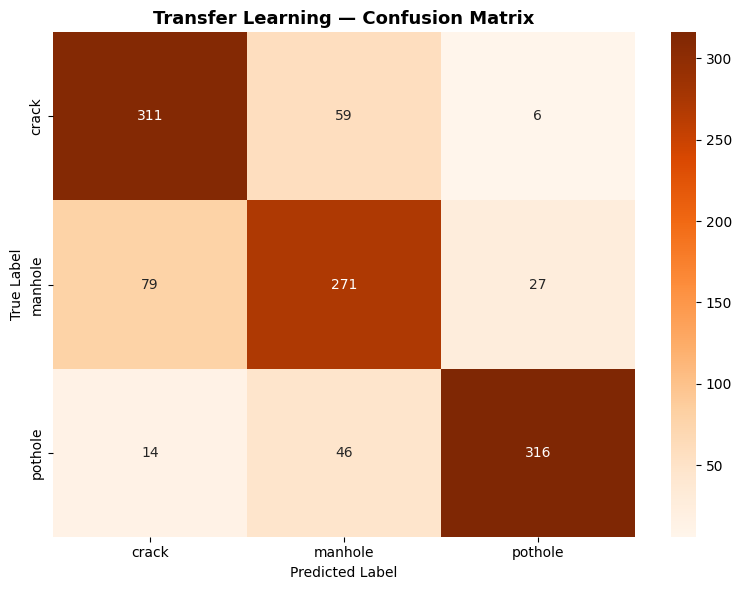

✅ TL Results saved!


In [20]:
# ============================================================
# Cell 9: Evaluate Transfer Learning on Test Set (FIXED)
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)

os.makedirs("results", exist_ok=True)
CLASSES = ["crack", "manhole", "pothole"]

# ── Predictions ──────────────────────────────────────────────
y_pred_probs = tl_model.predict(X_test, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)

# ── Metrics ──────────────────────────────────────────────────
test_loss, test_acc = tl_model.evaluate(X_test, y_test, verbose=0)
precision = precision_score(y_test, y_pred, average="weighted")
recall    = recall_score(y_test, y_pred, average="weighted")
f1        = f1_score(y_test, y_pred, average="weighted")

print("=" * 50)
print("   Transfer Learning — Test Results")
print("=" * 50)
print(f"  Test Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Test Loss      : {test_loss:.4f}")
print(f"  Precision      : {precision:.4f}")
print(f"  Recall         : {recall:.4f}")
print(f"  F1-Score       : {f1:.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASSES))

# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Transfer Learning — Confusion Matrix", fontweight="bold", fontsize=13)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("results/tl_confusion_matrix.png", dpi=150)
plt.show()

# ── Save results dict (safe if tl_train_time missing) ────────
try:
    tl_time = tl_train_time
except NameError:
    tl_time = None
    print("⚠️  tl_train_time not found — set to None")

tl_results = {
    "accuracy"  : test_acc,
    "precision" : precision,
    "recall"    : recall,
    "f1"        : f1,
    "train_time": tl_time,
    "params"    : tl_model.count_params()
}
print("✅ TL Results saved!")

           FINAL MODEL COMPARISON
             Metric CNN from Scratch Transfer Learning
      Test Accuracy           80.96%            79.54%
          Precision           0.8106            0.7986
             Recall           0.8096            0.7954
           F1-Score           0.8079            0.7962
Training Time (min)           183.70             28.25
   Total Parameters        8,913,603         3,048,003


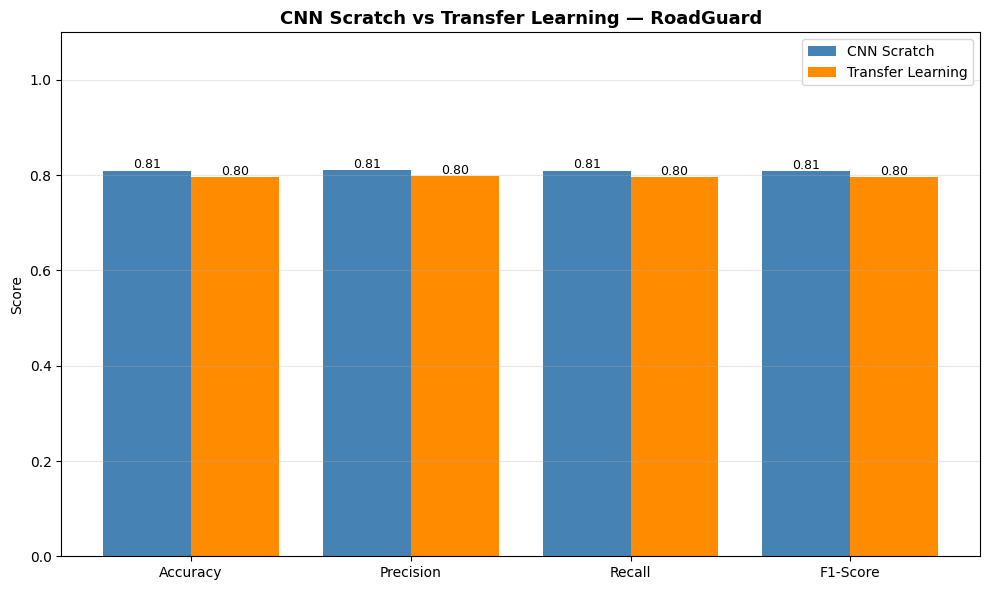

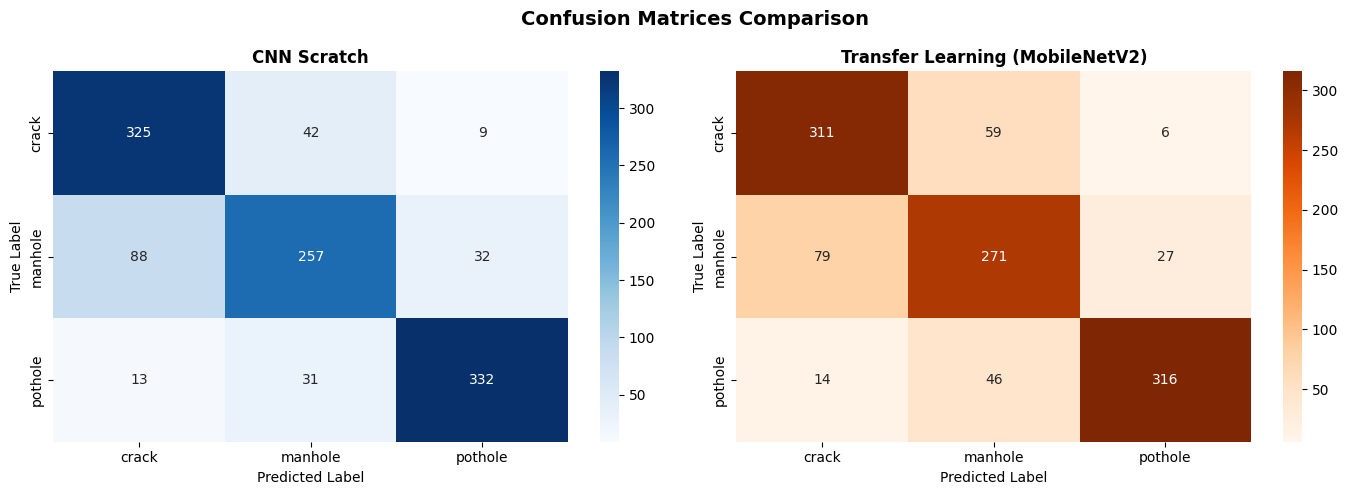

✅ All done! Results saved to results/


In [23]:
# ============================================================
# Cell 10: Final Comparison Table + Visualization (DYNAMIC)
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score)

os.makedirs("results", exist_ok=True)
CLASSES = ["crack", "manhole", "pothole"]

# ── Get Scratch results dynamically ──────────────────────────
y_pred_scratch   = np.argmax(cnn_scratch.predict(X_test, verbose=0), axis=1)
loss_s, acc_s    = cnn_scratch.evaluate(X_test, y_test, verbose=0)
scratch_results  = {
    "accuracy"  : acc_s,
    "precision" : precision_score(y_test, y_pred_scratch, average="weighted"),
    "recall"    : recall_score(y_test, y_pred_scratch, average="weighted"),
    "f1"        : f1_score(y_test, y_pred_scratch, average="weighted"),
    "train_time": 183.70 * 60,
    "params"    : cnn_scratch.count_params()
}

# ── Get TL results dynamically ────────────────────────────────
y_pred_tl      = np.argmax(tl_model.predict(X_test, verbose=0), axis=1)
loss_tl, acc_tl = tl_model.evaluate(X_test, y_test, verbose=0)
tl_results = {
    "accuracy"  : acc_tl,
    "precision" : precision_score(y_test, y_pred_tl, average="weighted"),
    "recall"    : recall_score(y_test, y_pred_tl, average="weighted"),
    "f1"        : f1_score(y_test, y_pred_tl, average="weighted"),
    "train_time": tl_train_time,
    "params"    : tl_model.count_params()
}

# ── Print comparison table ────────────────────────────────────
import pandas as pd
comparison = pd.DataFrame({
    "Metric": ["Test Accuracy", "Precision", "Recall", "F1-Score",
               "Training Time (min)", "Total Parameters"],
    "CNN from Scratch": [
        f"{scratch_results['accuracy']*100:.2f}%",
        f"{scratch_results['precision']:.4f}",
        f"{scratch_results['recall']:.4f}",
        f"{scratch_results['f1']:.4f}",
        f"{scratch_results['train_time']/60:.2f}",
        f"{scratch_results['params']:,}"
    ],
    "Transfer Learning": [
        f"{tl_results['accuracy']*100:.2f}%",
        f"{tl_results['precision']:.4f}",
        f"{tl_results['recall']:.4f}",
        f"{tl_results['f1']:.4f}",
        f"{tl_results['train_time']/60:.2f}",
        f"{tl_results['params']:,}"
    ]
})

print("=" * 65)
print("           FINAL MODEL COMPARISON")
print("=" * 65)
print(comparison.to_string(index=False))
print("=" * 65)

# ── Bar chart comparison ──────────────────────────────────────
metrics   = ["Accuracy", "Precision", "Recall", "F1-Score"]
scratch_v = [scratch_results['accuracy'], scratch_results['precision'],
             scratch_results['recall'],   scratch_results['f1']]
tl_v      = [tl_results['accuracy'], tl_results['precision'],
             tl_results['recall'],   tl_results['f1']]

x = range(len(metrics))
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar([i - 0.2 for i in x], scratch_v, width=0.4,
               label='CNN Scratch', color='steelblue')
bars2 = ax.bar([i + 0.2 for i in x], tl_v, width=0.4,
               label='Transfer Learning', color='darkorange')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.2f}", ha='center', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("CNN Scratch vs Transfer Learning — RoadGuard",
             fontweight="bold", fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join("results", "model_comparison.png"), dpi=150)
plt.show()

# ── Side-by-side Confusion Matrices ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title, cmap in zip(
    axes,
    [y_pred_scratch, y_pred_tl],
    ["CNN Scratch", "Transfer Learning (MobileNetV2)"],
    ["Blues", "Oranges"]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

plt.suptitle("Confusion Matrices Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join("results", "confusion_matrices_comparison.png"), dpi=150)
plt.show()

print("✅ All done! Results saved to results/")